In [6]:
import pandas as pd
import seaborn as sns

In [7]:
df = pd.read_csv(r"dataset_aula02_exercicio_modafina.csv")

In [8]:
df . head()

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9


In [9]:
df. info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   data_venda         700 non-null    str    
 1   categoria_produto  700 non-null    str    
 2   tamanho            700 non-null    str    
 3   preco              700 non-null    float64
 4   quantidade         700 non-null    int64  
 5   estado             700 non-null    str    
 6   forma_pagamento    700 non-null    str    
 7   nota_avaliacao     700 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 43.9 KB


In [10]:
df. columns.to_list()
df.isna().sum()

data_venda           0
categoria_produto    0
tamanho              0
preco                0
quantidade           0
estado               0
forma_pagamento      0
nota_avaliacao       0
dtype: int64

In [11]:
df ["faturamento"] = df["preco"] * df["quantidade"]
df.head()


,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao,faturamento
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1,177.95
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3,52.12
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9,640.35
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9,76.81
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9,264.78


In [12]:
faturamento_total = df["faturamento"].sum()
print(faturamento_total)

232687.91999999998


In [13]:
faturamento_formatado = f"{faturamento_total:,.2f}".replace(",","x").replace(".",",").replace("x",".")
print(f" O faturamento total foi de R${faturamento_formatado}")

 O faturamento total foi de R$232.687,92


In [17]:
df["categoria_produto"].value_counts().sort_values(ascending=True)


categoria_produto
Acessórios    101
Calçados      118
Vestidos      137
Calças        153
Camisetas     191
Name: count, dtype: int64

In [24]:
#Realiza agrupamento
df.groupby("categoria_produto")["faturamento"].sum().sort_values(ascending=True)


categoria_produto
Acessórios    17504.51
Camisetas     31637.03
Calças        51954.17
Vestidos      63743.92
Calçados      67848.29
Name: faturamento, dtype: float64

In [25]:
def converter(valor):
    return f"R${valor:,.2f}".replace(",","x").replace(".",",") .replace("x",".")

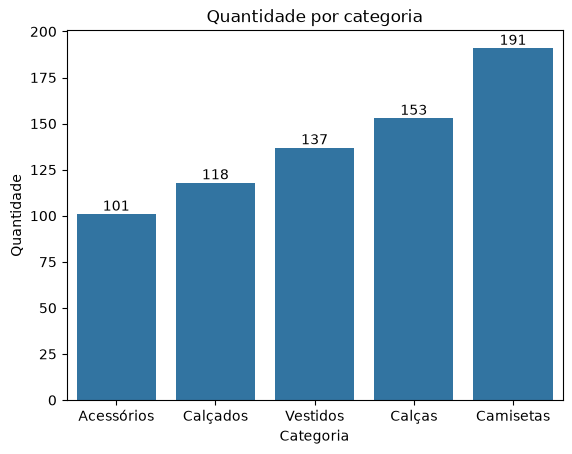

In [32]:
grafico = sns.countplot(data=df,x="categoria_produto",order=df["categoria_produto"].value_counts(ascending=True).index)
grafico.bar_label(grafico.containers[0])
grafico.set_title("Quantidade por categoria");
grafico.set_xlabel("Categoria");
grafico.set_ylabel("Quantidade");

C:\Users\FIC\AppData\Local\Temp\ipykernel_33168\1021853717.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico =sns.boxplot(data=df,x="categoria_produto",y="preco",palette="viridis");


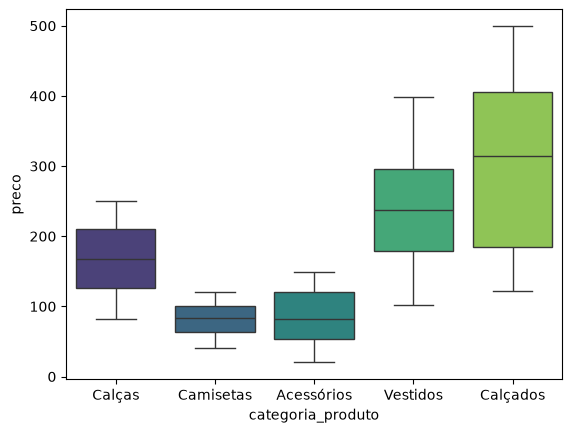

In [46]:
grafico =sns.boxplot(data=df,x="categoria_produto",y="preco",palette="viridis");

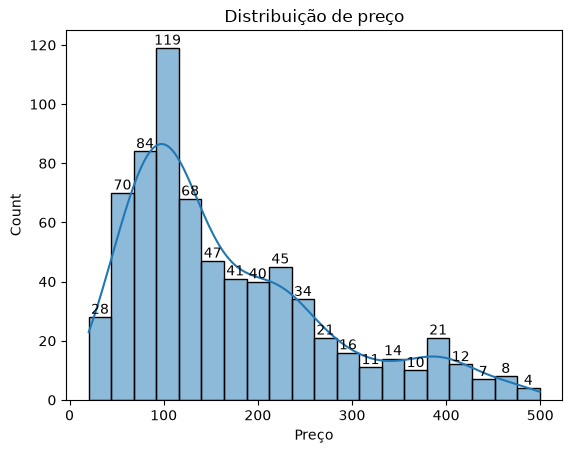

In [48]:
grafico= sns.histplot(data=df,x="preco",kde=True,bins=20)
grafico.bar_label(grafico.containers[0])
grafico.set_title("Distribuição de preço");
grafico.set_xlabel("Preço");

